**Data – Driven Insights into the Titanic Tragedy**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Titanic_df=sns.load_dataset('titanic')

In [3]:
Titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
Titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

**FEATURE DESCRIPTION :**-
                     


*   **survived** - Survival status of the passenger (0 = Died, 1 = Survived)



*   **pclass**   - Ticket class (1 = Upper class, 2 = Middle class, 3 = Lower class)



*   **sex** - Gender of the passenger (male/female)
*   **age** - Age of the passenger in years

*   **sibsp** - Number of siblings or spouses aboard the Titanic
*   **parch** - Number of parents or children aboard the Titanic

*   **fare**- Fare paid for the ticket
*   **embarked** - Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

*   **class** - Passenger class (First, Second, Third) — same as pclass but in string format
*   **who** - (man, woman, child)

*   **adult_male** - Whether the passenger is an adult male (True/False)
*   **deck** - 	Deck where the passenger's cabin was located (A, B, C, D, E, F, G, or NaN if unknown)


*   **embark_town** - Name of the embarkation town (Cherbourg, Queenstown, Southampton)
*   **alive**- survival status (yes/no) — same as survived but in string format

*   **alone** - Whether the passenger was traveling alone (True if no family members aboard, False otherwise)





























---


**PREPROCESSING OF TITANIC DATASET**

---



 Visualizing and Dealing with Missing Values :-

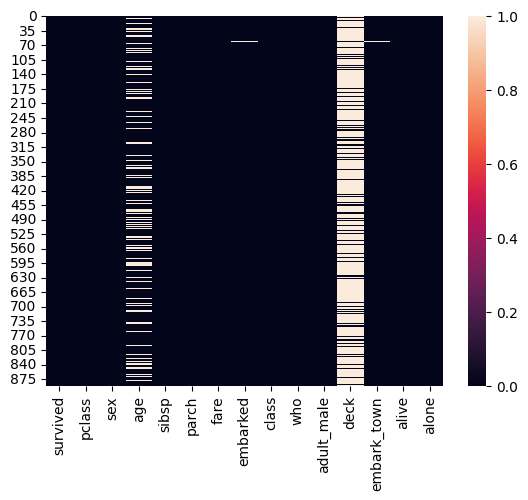

In [5]:
sns.heatmap(Titanic_df.isnull(),cbar=True)
plt.show()

In [6]:
Titanic_df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


**1. Dealing with 177 Missing Age Values**

**Normality Check of Age Distribution**

---



---

Before imputing missing age values, it is important to inspect whether the age data is normally distributed. This helps in choosing the correct imputation method.


     Visual Inspection of Age Distribution :-

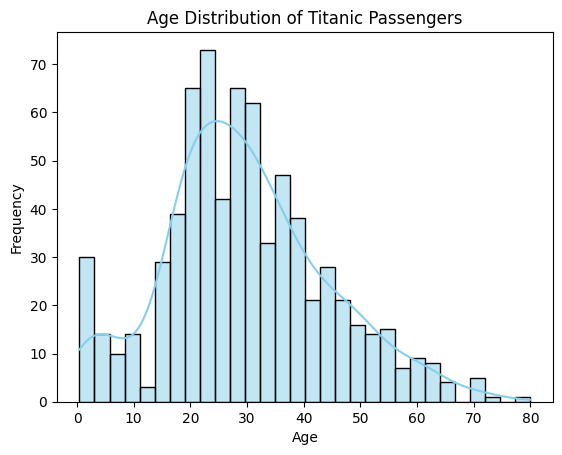

In [7]:
sns.histplot(Titanic_df['age'].dropna(), kde=True, bins=30, color='skyblue')        #HISTOGRAM PLOT
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

  **(INTERPRETAION)**
  
  The distribution is not symmetrical and does not follow the classic bell curve shape of a normal distribution. The histogram and KDE plot for the Titanic passengers' ages show that the distribution is right-skewed

**(CONCLUSION)**

  After performing visual check, we confirmed that the age data in the Titanic dataset is not normally distributed. Hence, median imputation, especially group-wise median based on passenger class and gender is selected as the most appropriate method for handling missing age values.





In [8]:
Titanic_df['age'] = Titanic_df['age'].fillna(
    Titanic_df.groupby(['pclass', 'sex'])['age'].transform('median')
)


print("Missing ages after imputation:", Titanic_df['age'].isnull().sum())

Missing ages after imputation: 0


**2. Dealing with 2 missing embarked column values**

---



    Since only 2 rows are missing out of 891, we can either:

    1. Impute with the most frequent value (mode)

    2. Drop the rows (acceptable because the dataset is large)

In [9]:
Titanic_df['embarked'] = Titanic_df['embarked'].fillna(Titanic_df['embarked'].mode()[0])     #IMPUTING MODE IN MISSING EMBARKED COLUMN VALUES


print("Most common embarked value: ",Titanic_df['embarked'].mode()[0])
print("Missing values after imputation:",Titanic_df['embarked'].isnull().sum())

Most common embarked value:  S
Missing values after imputation: 0


**(CONCLUSION)**

The embarked column had 2 missing values. Since the majority of passengers embarked from Southampton (S), we imputed the missing values using the mode of the embarked column.

**3. Dealing with 688 missing deck column values**

---





In [10]:
print("Missing values in deck column : ",(688/891)*100," %")      #MISSING VALUES PERCENTAGE

if 'Unknown' not in Titanic_df['deck'].cat.categories:
    Titanic_df['deck'] = Titanic_df['deck'].cat.add_categories('Unknown')

Titanic_df['deck'] = Titanic_df['deck'].fillna('Unknown')
print('\n')
print("Missing values after filling:", Titanic_df['deck'].isnull().sum())       #MISSING VALUES NOW

Missing values in deck column :  77.21661054994388  %


Missing values after filling: 0


**4. Dealing with 2 missing embark_town column values**

---





In [11]:
print("Most frequent embark_town:", Titanic_df['embark_town'].mode()[0])

Titanic_df['embark_town'] = Titanic_df['embark_town'].fillna(Titanic_df['embark_town'].mode()[0])      #Fill missing embark_town values with mode
print('\n')
print("Missing embark_town values after filling:", Titanic_df['embark_town'].isnull().sum())

Most frequent embark_town: Southampton


Missing embark_town values after filling: 0


In [12]:
Titanic_df.isnull().sum()          #All null values have been dealt

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


**Checking for Extreme Values :-**



---


**EXPLORATORY DATA ANALYSIS OF TITANIC SURVIVAL PATTERNS**

---






**Objective 1 :**To understand the overall fatality level of the incident.



In [13]:
survival_counts = Titanic_df['survived'].value_counts()    #Counting the number of survivors and deaths

deaths = survival_counts[0]
survivors = survival_counts[1]

print(f"Number of Deaths: {deaths}")
print(f"Number of Survivors: {survivors}")

Number of Deaths: 549
Number of Survivors: 342


In [14]:
total_passengers = Titanic_df['survived'].count()          #Calculating Survival and Death Percentages

death_ratio = (deaths / total_passengers) * 100
survival_ratio = (survivors / total_passengers) * 100

print(f"Death Ratio: {death_ratio:.2f}%")
print(f"Survival Ratio: {survival_ratio:.2f}%")

Death Ratio: 61.62%
Survival Ratio: 38.38%


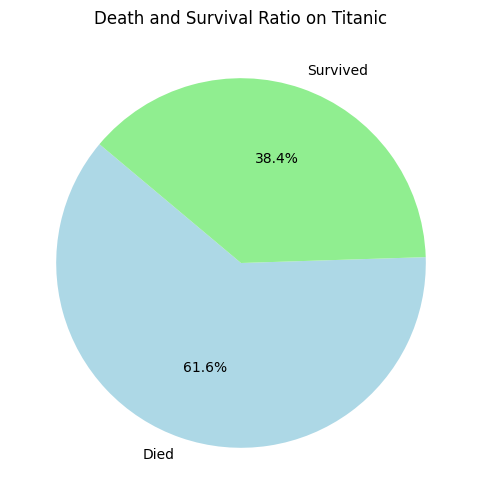

In [15]:
labels = ['Died', 'Survived']                             #Visualizing with Pie Chart
sizes = [deaths, survivors]
colors = ['lightblue', 'lightgreen']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Death and Survival Ratio on Titanic')
plt.show()

**(INTERPRETATION)**

The pie chart shows that approximately **62%** of the passengers died while **38%** survived.
Since the death rate is greater than 50%, the Titanic disaster was extremely deadly with a high fatality rate.

This analysis shows the heartbreaking scale of human loss in the Titanic tragedy and encourages us to look deeper into the factors that influenced who survived and who didn’t.

---



---



**Objective 2** :Analyzing the Impact of Gender on Survival Rates

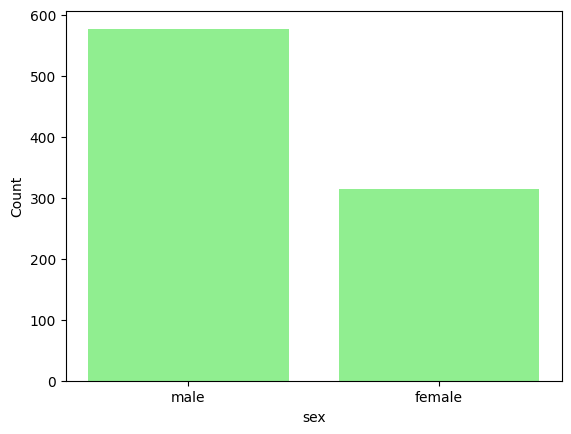

In [16]:
gender_count=Titanic_df['sex'].value_counts()
plt.bar(gender_count.index,gender_count.values,color='lightgreen')
plt.xlabel('sex')
plt.ylabel('Count')
plt.show()

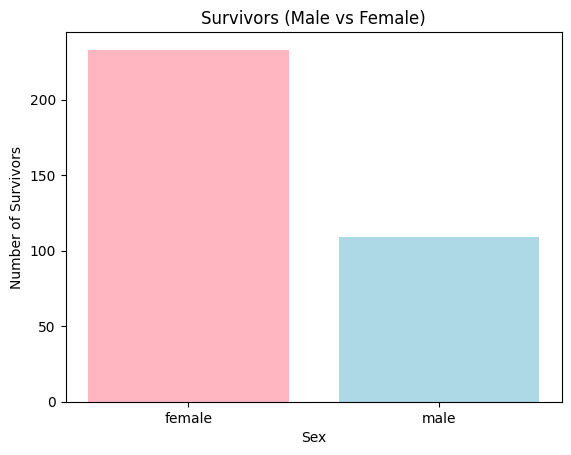

In [17]:
survivors=Titanic_df[Titanic_df['survived'] == 1]

survivor_counts = survivors['sex'].value_counts()
plt.bar(survivor_counts.index,survivor_counts.values,color=['lightpink','lightblue'])
plt.title("Survivors (Male vs Female)")
plt.xlabel('Sex')
plt.ylabel('Number of Survivors')
plt.show()

**(INTERPRETATION)**

The bar plot clearly shows that more women survived than men. Although the total number of male passengers was higher on the Titanic, the number of female survivors was significantly greater.
**This trend suggests that women were more likely to survive, reflecting a conscious decision to prioritize them during lifeboat boarding.**
**This may also hint that some male passengers willingly assisted women in evacuation, adding a layer of humanity behind the numbers.**


---



---



**Objective 3** :Analyzing the Impact of Passenger Class on Survival Rates



In [18]:
class_survival_counts = Titanic_df.groupby('pclass')['survived'].value_counts().unstack()    #Counting survivors and deaths by passenger class

print("Survival Counts by Passenger Class:")
print(class_survival_counts)

class_survival_percent = Titanic_df.groupby('pclass')['survived'].mean() * 100             #Calculating survival rate by class
print("\nSurvival Percentage by Passenger Class:")
print(class_survival_percent)

Survival Counts by Passenger Class:
survived    0    1
pclass            
1          80  136
2          97   87
3         372  119

Survival Percentage by Passenger Class:
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


/tmp/ipython-input-19-1107296035.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_survival_percent.index, y=class_survival_percent.values, palette='pastel')


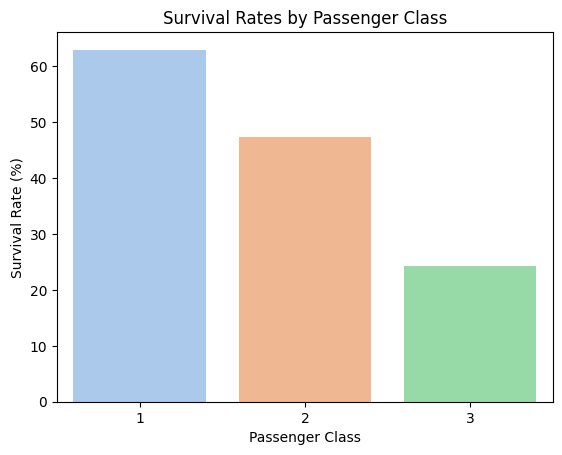

In [19]:
sns.barplot(x=class_survival_percent.index, y=class_survival_percent.values, palette='pastel')
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.show()

**(INTERPRETATION)**

The survival rates show a clear decreasing trend from 1st class to 3rd class:

1st Class Survival Rate: **Highest**

2nd Class Survival Rate: **Moderate**

3rd Class Survival Rate: **Lowest**

Being in a higher class seems to have significantly improved survival chances, Maybe being in a higher class meant having not just better seats, but also better chances of survival — like being closer to lifeboats, having more life jackets available, or getting faster help. Sadly, many third-class passengers may not have had the same access or time to escape.

---



---




**Objective 4:** Analyzing the Impact of Age on Survival Rates

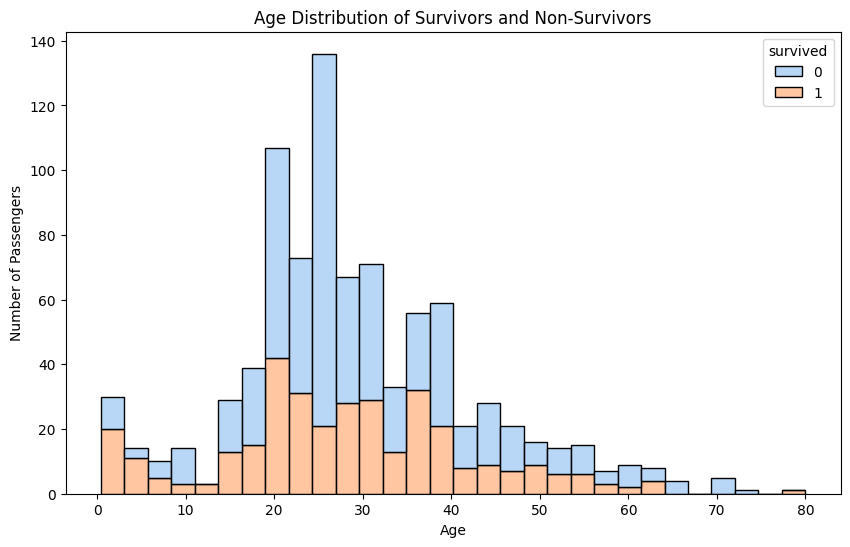

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=Titanic_df, x='age', hue='survived', multiple='stack', palette='pastel', bins=30)

plt.title('Age Distribution of Survivors and Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

**(INTERPRETATION)**

The data suggests that being younger may have increased the chance of survival. It’s possible that more life-saving resources were made available to children, or that adults and crew members actively helped them during the rescue operations. Meanwhile, adults and seniors may have faced lower chances due to either lack of access or selfless acts to save younger passengers.

---



---



**Objective 5:** Analyzing the Impact of Family Size on Survival Rates

In [21]:
Titanic_df['family_size'] = Titanic_df['sibsp'] + Titanic_df['parch'] + 1      #Analyzing family sizes

family_survival = Titanic_df.groupby('family_size')['survived'].mean() * 100   #Calculating survival percentage
print("Survival Rate by Family Size:\n", family_survival)

Survival Rate by Family Size:
 family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64


/tmp/ipython-input-22-9124709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_survival.index, y=family_survival.values, palette='pastel')


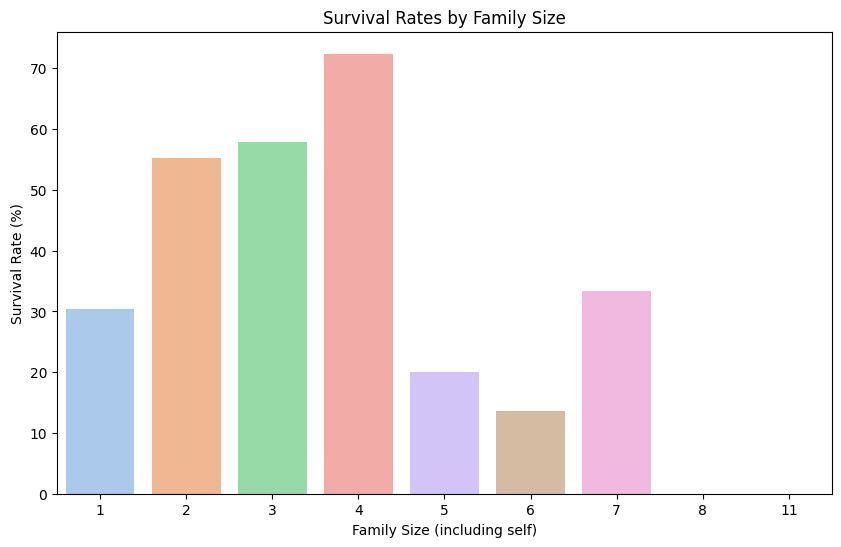

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=family_survival.index, y=family_survival.values, palette='pastel')

plt.title('Survival Rates by Family Size')
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate (%)')
plt.show()

**(INTERPRETATION)**

**Traveling Alone** = Lower Survival

**Small/Medium Family(2-4 members)** = Higher Survival

**Large Family** = Lower Survival



*   **Passengers traveling alone** had lower survival rates, possibly due to limited assistance and being overlooked during lifeboat boarding.
*   Having a **small or medium family (2-4 members)** increased the chances of survival. These passengers might have found it easier to stay together and support each other during evacuation.

*   **Large families** had reduced survival chances, likely because staying together and securing spots for many family members in lifeboats was difficult in the chaos.

---



---








**Objective 6:**  Fare Analysis and Survival

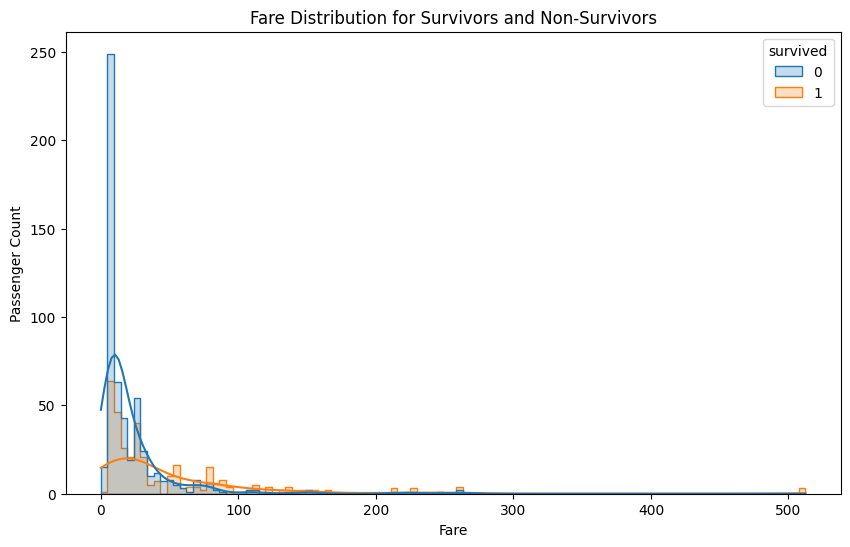

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(data=Titanic_df, x='fare', hue='survived', element='step', kde=True)
plt.title('Fare Distribution for Survivors and Non-Survivors')
plt.xlabel('Fare')
plt.ylabel('Passenger Count')
plt.show()

**(INTERPRETATION)**

Higher fares were linked to higher survival chances. Wealth and class played a major role in determining who had better access to lifeboats and evacuation assistance.
**This is likely because higher-class passengers (who paid more) had better cabin locations and faster access to lifeboats.**

---



---





---





---





---





---





---








---





---

